In [ ]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import numpy as np
import torch
import torch.nn.functional as F
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
from tqdm import tqdm
import sys

CODE_DIR    = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code'
CKPT_DIR    = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/training'
BASE_OUTPUT = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/test'
os.makedirs(BASE_OUTPUT, exist_ok=True)
sys.path.append(CODE_DIR)

from lib.model.Baseline      import CNN
from lib.model.FusionNet     import FusionNet
from lib.model.FusionNetRes  import FusionNetRes
from lib.model.FusionNetASPP import FusionNetASPP

### ── Only change these ──────────────────────────────────────────────────
MODEL_NAME = 'fusionnetaspp'   # 'baseline' | 'fusionnet' | 'fusionnetres' | 'fusionnetaspp'
POSTFIX    = '3'

# Paths
OUTPUT_DIR = os.path.join(BASE_OUTPUT, MODEL_NAME + POSTFIX)
os.makedirs(OUTPUT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, MODEL_NAME, f'best_model_{POSTFIX}.pth')

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
print(f'Using device: {device}')

# Load checkpoint
ckpt        = torch.load(CKPT_PATH, map_location=device, weights_only=True)
in_channels = ckpt['in_channels']
features    = ckpt['features']
model_name  = ckpt.get('model_name', MODEL_NAME)
print(f'Checkpoint  : epoch={ckpt["epoch"]}  val_rmse={ckpt["val_rmse"]:.2f}%  val_mae={ckpt["val_mae"]:.2f}%')

_registry = {
    'Baseline':      lambda: CNN(in_channels=in_channels, features=features),
    'FusionNet':     lambda: FusionNet(in_channels=in_channels, features=features),
    'FusionNetRes':  lambda: FusionNetRes(in_channels=in_channels, features=features),
    'FusionNetASPP': lambda: FusionNetASPP(in_channels=in_channels, features=features),
}
model = _registry[model_name]().to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Model loaded: {model_name}  features={features}  in_channels={in_channels}')

# Colormaps
cmap_bt   = plt.cm.Greys.copy();   cmap_bt.set_bad('beige')
cmap_sic  = plt.cm.Blues_r.copy(); cmap_sic.set_bad('lightgray')
cmap_diff = plt.cm.bwr.copy();     cmap_diff.set_bad('lightgray')

Using device: cpu
Checkpoint  : epoch=177  val_rmse=5.90%  val_mae=2.39%
Model loaded: FusionNetASPP  features=128  in_channels=14


### Predict from unseen AMSR2 + SIC pair

AMSR2 : /dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/2021/02/04/AMSR2_S1A_EW_GRDM_1SDH_20210204T053353_20210204T053457_036436_0446EB_F69C.nc
SIC   : /dmidata/projects/asip-cms/reproc/2021/02/04/S1A_EW_GRDM_1SDH_20210204T053353_20210204T053457_036436_0446EB_F69C_SIC.tiff
AMSR2: (14, 214, 207)
SIC: (214, 207)  valid pixels: 35350


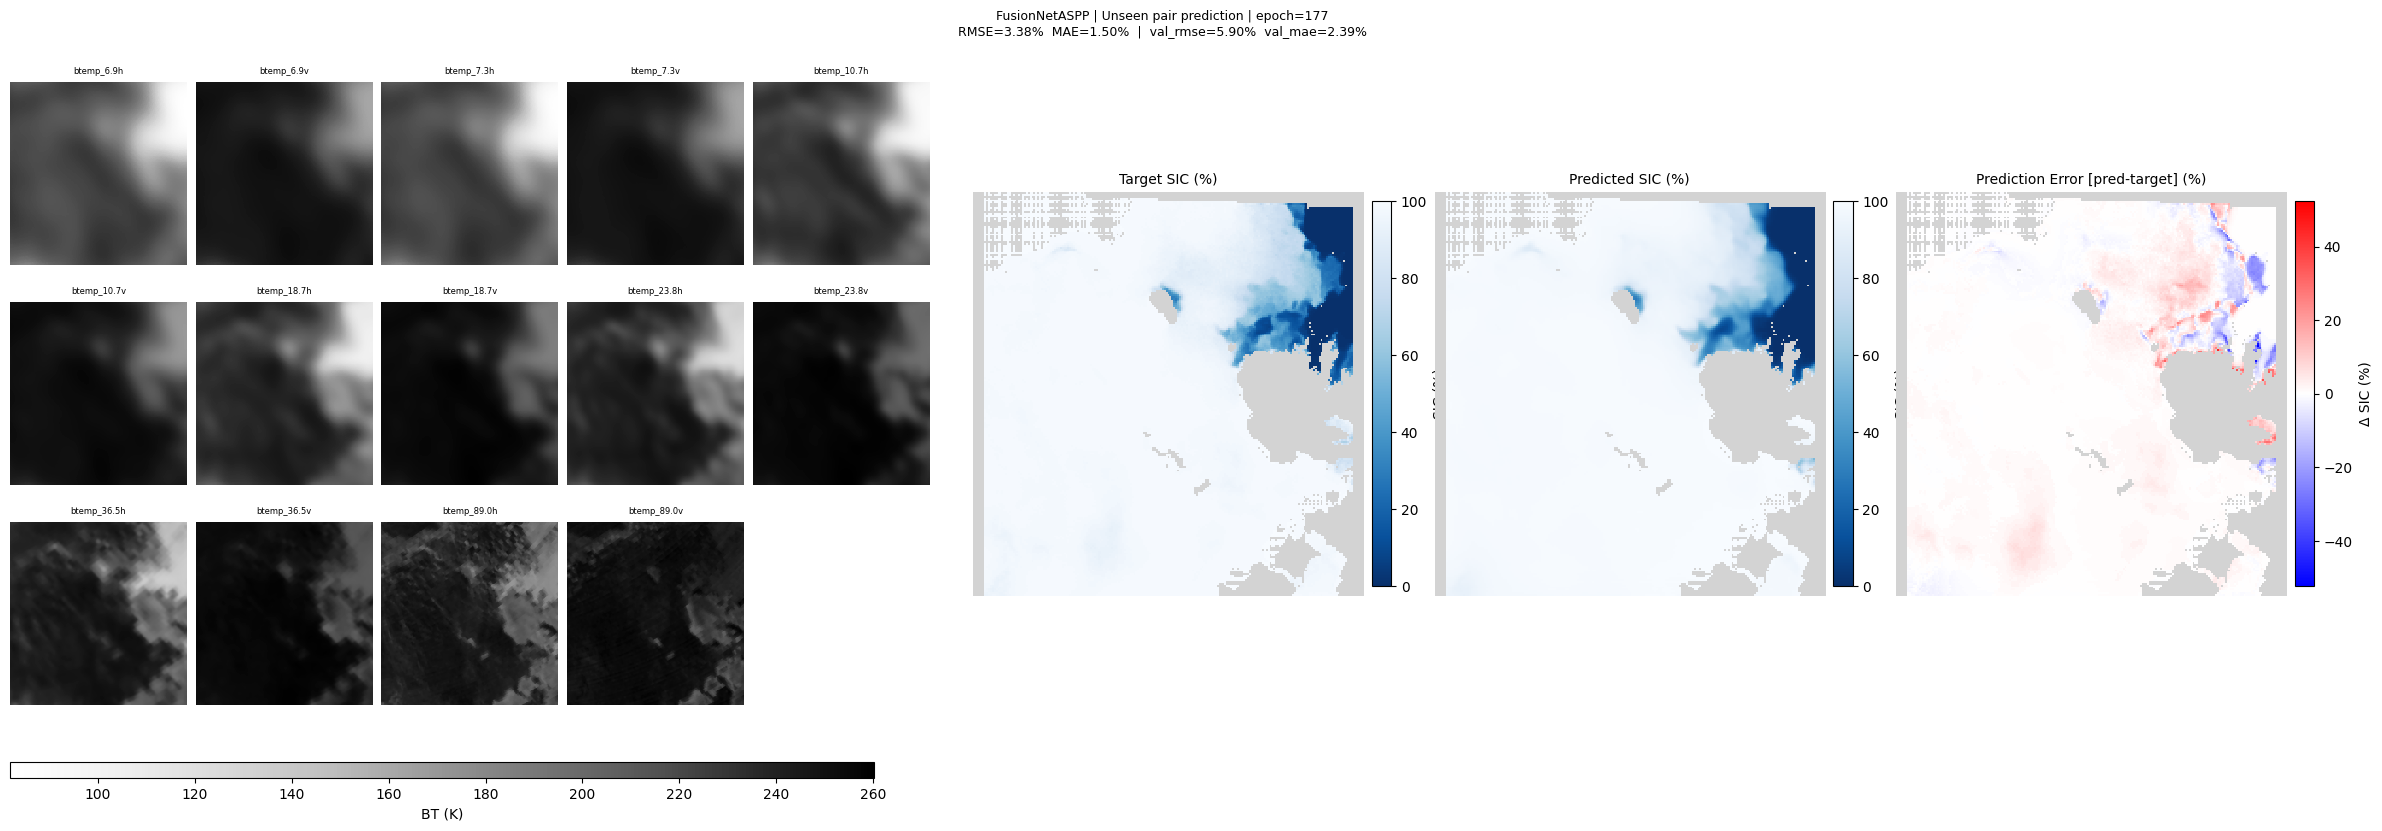

Unseen pair — RMSE: 3.38%  MAE: 1.50%


In [8]:
AMSR2_PATH_PAIR = '/dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/2021/02/04/AMSR2_S1A_EW_GRDM_1SDH_20210204T053353_20210204T053457_036436_0446EB_F69C.nc'
SIC_BASE_DIR    = '/dmidata/projects/asip-cms/reproc'

# Derive SIC path from AMSR2 filename
amsr2_basename  = os.path.basename(AMSR2_PATH_PAIR)  
scene_id        = amsr2_basename.replace('AMSR2_', '').replace('.nc', '')  
sic_filename    = scene_id + '_SIC.tiff'                    

parts    = AMSR2_PATH_PAIR.split('/')
date_idx = parts.index('AMSR2') + 1                           # find AMSR2 dir then step forward
y, m, d  = parts[date_idx], parts[date_idx+1], parts[date_idx+2]

SIC_PATH_PAIR = os.path.join(SIC_BASE_DIR, y, m, d, sic_filename)
print(f'AMSR2 : {AMSR2_PATH_PAIR}')
print(f'SIC   : {SIC_PATH_PAIR}')
assert os.path.exists(SIC_PATH_PAIR), f'SIC file not found: {SIC_PATH_PAIR}'

# Load AMSR2
with xr.open_dataset(AMSR2_PATH_PAIR, engine='h5netcdf') as ds:
    ch_names  = [v for v in ds.data_vars if 'swath' not in v.lower()]
    amsr2_np  = ds[ch_names].to_array().values.astype(np.float32)
amsr2_h, amsr2_w = amsr2_np.shape[-2], amsr2_np.shape[-1]
print(f'AMSR2: {amsr2_np.shape}')

# Load SIC and bicubic-downsample to AMSR2 resolution
with rioxarray.open_rasterio(SIC_PATH_PAIR) as da:
    sic_native = da.values[0].astype(np.float32)  # (H_sic, W_sic)

invalid    = (sic_native == 254) | (sic_native == 255)
sic_filled = sic_native.copy()
sic_filled[invalid] = np.nan

sic_t    = torch.from_numpy(sic_filled)[None, None]
sic_lr_t = F.interpolate(sic_t, size=(amsr2_h, amsr2_w), mode='bicubic', align_corners=False)
sic_lr   = sic_lr_t.numpy()[0, 0]
mask_lr  = np.isnan(sic_lr) | (sic_lr < 0.0) | (sic_lr > 100.0)
sic_lr   = np.clip(sic_lr, 0.0, 100.0)
sic_np   = np.where(mask_lr, np.nan, sic_lr)
print(f'SIC: {sic_np.shape}  valid pixels: {(~mask_lr).sum()}')

# Run inference
amsr2_t     = torch.from_numpy(amsr2_np)[None].to(device)  # (1, 14, H, W)
target_size = (amsr2_h, amsr2_w)

with torch.no_grad():
    pred_t = model(amsr2_t, target_size=target_size)

pred_np = np.clip(pred_t[0, 0].cpu().numpy(), 0, 100)
pred_np = np.where(mask_lr, np.nan, pred_np)
diff_np = pred_np - sic_np
abs_max = np.nanmax(np.abs(diff_np))

# Plot — 4 columns: AMSR2 | Target SIC | Prediction | Difference
fig = plt.figure(figsize=(24, 8))
gs  = gridspec.GridSpec(1, 4, figure=fig,
                        width_ratios=[2.2, 1, 1, 1],
                        left=0.02, right=0.98, top=0.90, bottom=0.10,
                        wspace=0.08)

# AMSR2 channels
gs_ch  = gs[0, 0].subgridspec(3, 5, hspace=0.10, wspace=0.05)
ims_bt = []
for i, ch in enumerate(ch_names[:14]):
    row, col = divmod(i, 5)
    ax = fig.add_subplot(gs_ch[row, col])
    im = ax.imshow(amsr2_np[i], cmap=cmap_bt, interpolation='nearest')
    ax.set_title(ch, fontsize=6)
    ax.axis('off')
    ims_bt.append(im)
if len(ch_names) < 15:
    fig.add_subplot(gs_ch[2, 4]).axis('off')
vmin_bt, vmax_bt = amsr2_np.min(), amsr2_np.max()
for im in ims_bt: im.set_clim(vmin_bt, vmax_bt)
# cax_bt = fig.add_axes([0.02, 0.04, 0.42, 0.015])
cax_bt = fig.add_axes([0.02, 0.02, 0.36, 0.02])
fig.colorbar(ims_bt[0], cax=cax_bt, orientation='horizontal', label='BT (K)')

# Target SIC
ax_tgt = fig.add_subplot(gs[0, 1])
im_tgt = ax_tgt.imshow(sic_np, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
ax_tgt.set_title('Target SIC (%)', fontsize=10)
ax_tgt.axis('off')
plt.colorbar(im_tgt, ax=ax_tgt, fraction=0.046, pad=0.02, label='SIC (%)')

# Prediction
ax_pred = fig.add_subplot(gs[0, 2])
im_pred = ax_pred.imshow(pred_np, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
ax_pred.set_title(f'Predicted SIC (%)', fontsize=10)
ax_pred.axis('off')
plt.colorbar(im_pred, ax=ax_pred, fraction=0.046, pad=0.02, label='SIC (%)')

# Difference
ax_diff = fig.add_subplot(gs[0, 3])
im_diff = ax_diff.imshow(diff_np, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
ax_diff.set_title('Prediction Error [pred-target] (%)', fontsize=10)
ax_diff.axis('off')
plt.colorbar(im_diff, ax=ax_diff, fraction=0.046, pad=0.02, label='Δ SIC (%)')

# Compute metrics on valid pixels
valid    = ~mask_lr
rmse     = np.sqrt(np.nanmean(diff_np[valid]**2))
mae      = np.nanmean(np.abs(diff_np[valid]))

fig.suptitle(
    f'{model_name} | Unseen pair prediction | epoch={ckpt["epoch"]}\n'
    f'RMSE={rmse:.2f}%  MAE={mae:.2f}%  |  '
    f'val_rmse={ckpt["val_rmse"]:.2f}%  val_mae={ckpt["val_mae"]:.2f}%',
    fontsize=9,
)
plt.show()
print(f'Unseen pair — RMSE: {rmse:.2f}%  MAE: {mae:.2f}%')


### Full swath prediction

Reference shape (low freq): 2035 × 486
  Upsampling btemp_6.9h: (2035, 243) → (2035, 486)
  Upsampling btemp_6.9v: (2035, 243) → (2035, 486)
  Upsampling btemp_7.3h: (2035, 243) → (2035, 486)
  Upsampling btemp_7.3v: (2035, 243) → (2035, 486)
  Upsampling btemp_10.7h: (2035, 243) → (2035, 486)
  Upsampling btemp_10.7v: (2035, 243) → (2035, 486)
  Upsampling btemp_18.7h: (2035, 243) → (2035, 486)
  Upsampling btemp_18.7v: (2035, 243) → (2035, 486)
  Upsampling btemp_23.8h: (2035, 243) → (2035, 486)
  Upsampling btemp_23.8v: (2035, 243) → (2035, 486)
  Upsampling btemp_36.5h: (2035, 243) → (2035, 486)
  Upsampling btemp_36.5v: (2035, 243) → (2035, 486)
AMSR2 shape: (14, 2035, 486)  channels: ['btemp_6.9h', 'btemp_6.9v', 'btemp_7.3h', 'btemp_7.3v', 'btemp_10.7h', 'btemp_10.7v', 'btemp_18.7h', 'btemp_18.7v', 'btemp_23.8h', 'btemp_23.8v', 'btemp_36.5h', 'btemp_36.5v', 'btemp_89.0h', 'btemp_89.0v']
Prediction shape: (2035, 486)  min=0.0  max=100.0


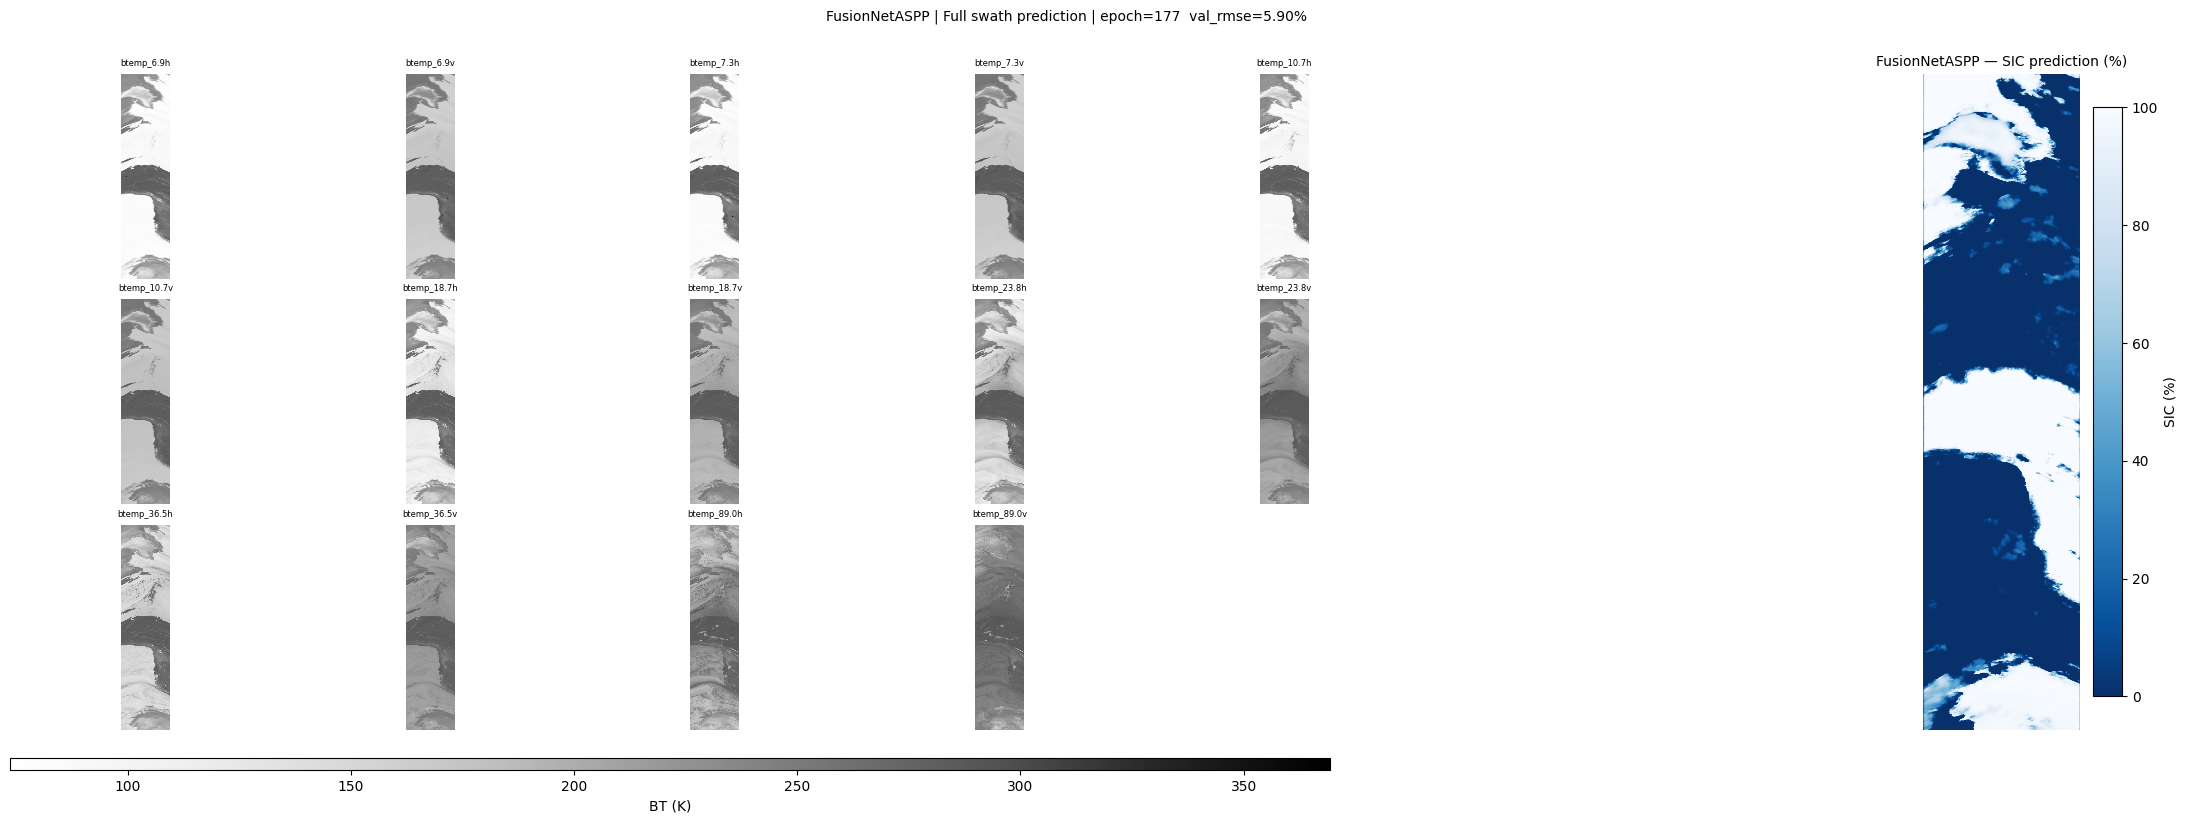

AMSR2 shape: (14, 2035, 486)  channels: ['btemp_6.9h', 'btemp_6.9v', 'btemp_7.3h', 'btemp_7.3v', 'btemp_10.7h', 'btemp_10.7v', 'btemp_18.7h', 'btemp_18.7v', 'btemp_23.8h', 'btemp_23.8v', 'btemp_36.5h', 'btemp_36.5v', 'btemp_89.0h', 'btemp_89.0v']
Prediction shape: (2035, 486)  min=0.0  max=29.6


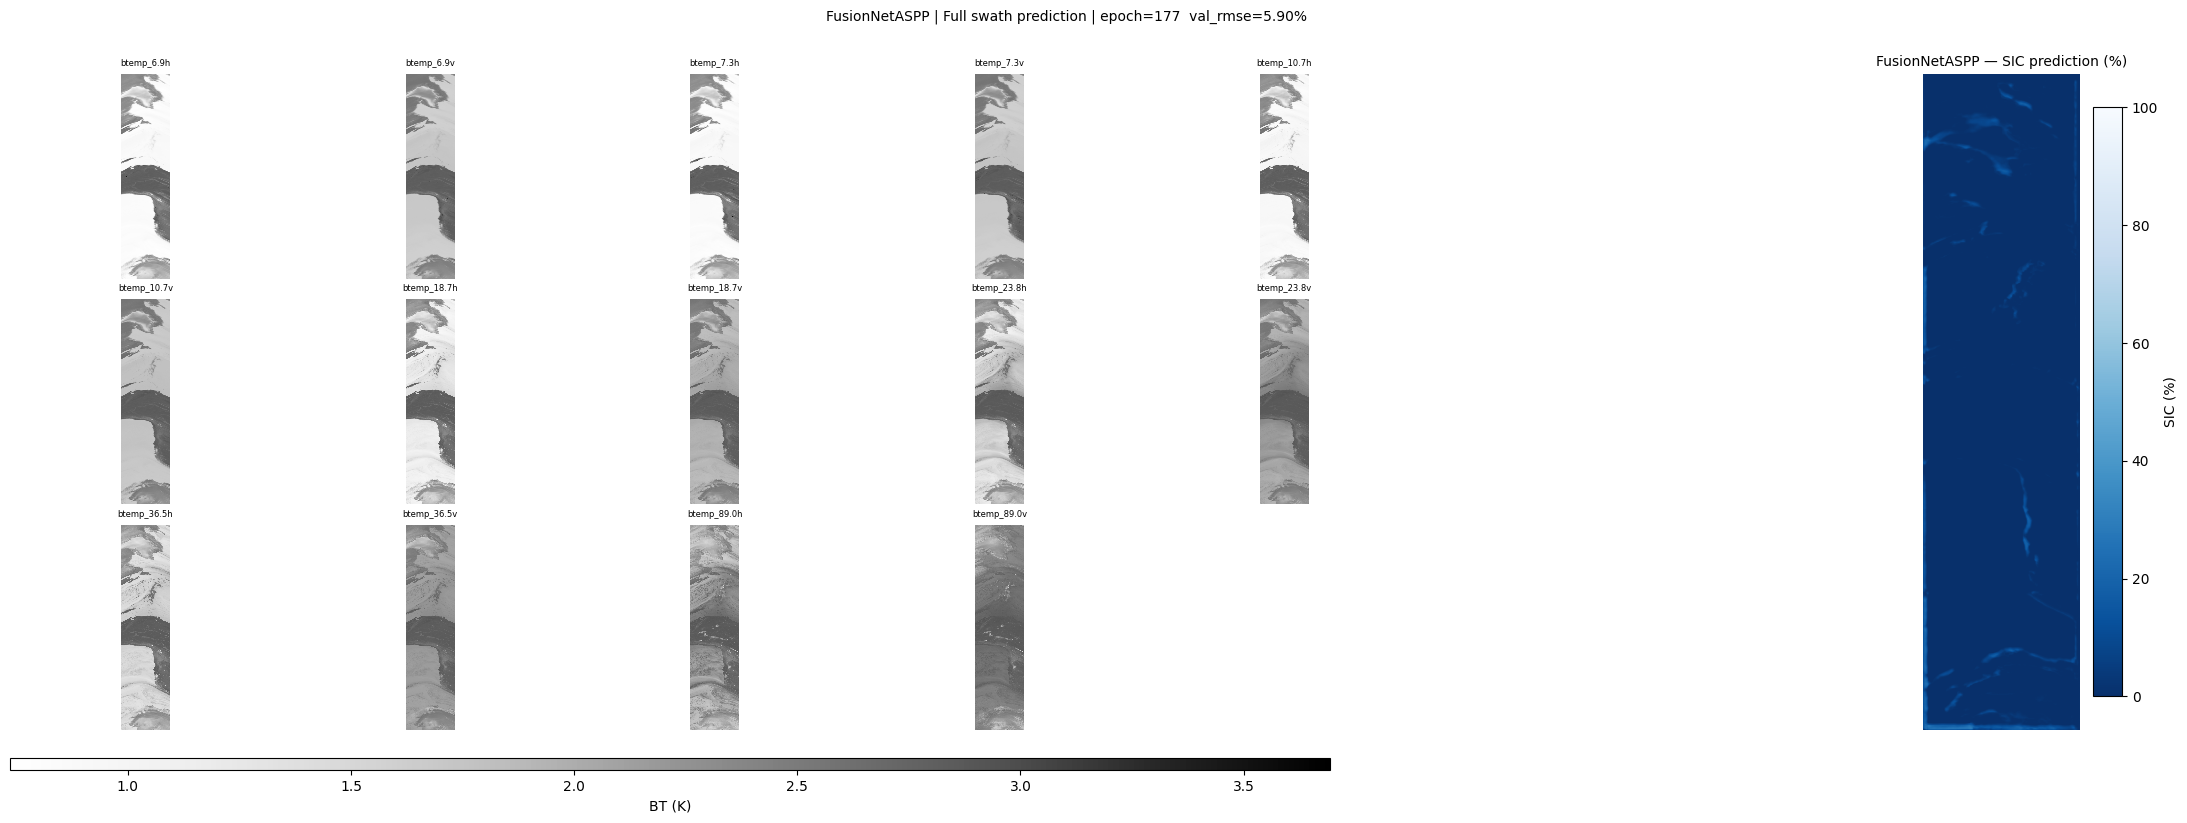

In [9]:
### ── Set path to AMSR2 .h5 swath file ───────────────────────────────────
AMSR2_PATH = '/dmidata/projects/asip-cms/amsr2/2021/02/04/GW1AM2_202102040542_004D_L1SGBTBR_2220220.h5'  # ← change this
### ──────────────────────────────────────────────────────────────────────

# Load AMSR2 swath
with xr.open_dataset(AMSR2_PATH, engine='h5netcdf', phony_dims='sort') as ds:

    # Extract the 14 brightness temperature channels in the same order as training
    # Use 89A (not 89B) for the 89 GHz channels
    bt_vars = {
        'btemp_6.9h':  'Brightness Temperature (6.9GHz,H)',
        'btemp_6.9v':  'Brightness Temperature (6.9GHz,V)',
        'btemp_7.3h':  'Brightness Temperature (7.3GHz,H)',
        'btemp_7.3v':  'Brightness Temperature (7.3GHz,V)',
        'btemp_10.7h': 'Brightness Temperature (10.7GHz,H)',
        'btemp_10.7v': 'Brightness Temperature (10.7GHz,V)',
        'btemp_18.7h': 'Brightness Temperature (18.7GHz,H)',
        'btemp_18.7v': 'Brightness Temperature (18.7GHz,V)',
        'btemp_23.8h': 'Brightness Temperature (23.8GHz,H)',
        'btemp_23.8v': 'Brightness Temperature (23.8GHz,V)',
        'btemp_36.5h': 'Brightness Temperature (36.5GHz,H)',
        'btemp_36.5v': 'Brightness Temperature (36.5GHz,V)',
        'btemp_89.0h': 'Brightness Temperature (89.0GHz-A,H)',  # use 89A
        'btemp_89.0v': 'Brightness Temperature (89.0GHz-A,V)',  # use 89A
    }

    channel_names = list(bt_vars.keys())
    arrays = [ds[v].values.astype(np.float32) for v in bt_vars.values()]

with xr.open_dataset(AMSR2_PATH, engine='h5netcdf', phony_dims='sort') as ds:
    lat = ds['Latitude of Observation Point for 89A'].values.astype(np.float32)
    lon = ds['Longitude of Observation Point for 89A'].values.astype(np.float32)

# Reference shape from latitude for 89 GHz channels
target_h, target_w = lat.shape
print(f'Reference shape (low freq): {target_h} × {target_w}')

resampled = []
# Downsample 89 GHz (2035, 486) → (2035, 243) to match lower frequency channels
# for name, arr in zip(channel_names, arrays):
#     if arr.shape != (target_h, target_w):
#         print(f'  Resampling {name}: {arr.shape} → ({target_h}, {target_w})')
#         t   = torch.from_numpy(arr)[None, None]
#         t   = F.interpolate(t, size=(target_h, target_w), mode='bicubic', align_corners=False)
#         arr = t.numpy()[0, 0]
#     resampled.append(arr)

# Upsample low-freq channels (2035, 243) → (2035, 486) to match 89 GHz
for name, arr in zip(channel_names, arrays):
    if arr.shape != (target_h, target_w):
        print(f'  Upsampling {name}: {arr.shape} → ({target_h}, {target_w})')
        t   = torch.from_numpy(arr)[None, None]
        t   = F.interpolate(t, size=(target_h, target_w), mode='bicubic', align_corners=False)
        arr = t.numpy()[0, 0]
    resampled.append(arr)

amsr2_np = np.stack(resampled, axis=0)  # (14, 2035, 243)
amsr2_np = amsr2_np/100.0
print(f'AMSR2 shape: {amsr2_np.shape}  channels: {channel_names}')
assert amsr2_np.shape[0] == 14

# Build model input
amsr2_t = torch.from_numpy(amsr2_np)[None].to(device)  # (1, 14, H, W)
target_size = (amsr2_np.shape[-2], amsr2_np.shape[-1])

with torch.no_grad():
    pred_t = model(amsr2_t, target_size=target_size)

pred_swath = pred_t[0, 0].cpu().numpy()  # (H, W)
pred_swath = np.clip(pred_swath, 0, 100)
print(f'Prediction shape: {pred_swath.shape}  min={pred_swath.min():.1f}  max={pred_swath.max():.1f}')

# Plot — AMSR2 channels (3×5) + prediction
fig = plt.figure(figsize=(22, 8))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2.2, 1],
                        left=0.02, right=0.98, top=0.90, bottom=0.08, wspace=0.06)
gs_ch = gs[0, 0].subgridspec(3, 5, hspace=0.10, wspace=0.05)

ims_bt = []
for i, ch in enumerate(channel_names[:14]):
    row, col = divmod(i, 5)
    ax = fig.add_subplot(gs_ch[row, col])
    im = ax.imshow(amsr2_np[i], cmap=cmap_bt, interpolation='nearest')
    ax.set_title(ch, fontsize=6)
    ax.axis('off')
    ims_bt.append(im)
if len(channel_names) < 15:
    fig.add_subplot(gs_ch[2, 4]).axis('off')

vmin_bt, vmax_bt = amsr2_np.min(), amsr2_np.max()
for im in ims_bt: im.set_clim(vmin_bt, vmax_bt)
cax_bt = fig.add_axes([0.02, 0.03, 0.60, 0.015])
fig.colorbar(ims_bt[0], cax=cax_bt, orientation='horizontal', label='BT (K)')

ax_pred = fig.add_subplot(gs[0, 1])
im_pred = ax_pred.imshow(pred_swath, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
ax_pred.set_title(f'{model_name} — SIC prediction (%)', fontsize=10)
ax_pred.axis('off')
plt.colorbar(im_pred, ax=ax_pred, fraction=0.046, pad=0.02, label='SIC (%)')

fig.suptitle(f'{model_name} | Full swath prediction | epoch={ckpt["epoch"]}  '
             f'val_rmse={ckpt["val_rmse"]:.2f}%', fontsize=10)

plt.show()
amsr2_np = amsr2_np/100.0
print(f'AMSR2 shape: {amsr2_np.shape}  channels: {channel_names}')
assert amsr2_np.shape[0] == 14

# Build model input
amsr2_t = torch.from_numpy(amsr2_np)[None].to(device)  # (1, 14, H, W)
target_size = (amsr2_np.shape[-2], amsr2_np.shape[-1])

with torch.no_grad():
    pred_t = model(amsr2_t, target_size=target_size)

pred_swath = pred_t[0, 0].cpu().numpy()  # (H, W)
pred_swath = np.clip(pred_swath, 0, 100)
print(f'Prediction shape: {pred_swath.shape}  min={pred_swath.min():.1f}  max={pred_swath.max():.1f}')

# Plot — AMSR2 channels (3×5) + prediction
fig = plt.figure(figsize=(22, 8))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2.2, 1],
                        left=0.02, right=0.98, top=0.90, bottom=0.08, wspace=0.06)
gs_ch = gs[0, 0].subgridspec(3, 5, hspace=0.10, wspace=0.05)

ims_bt = []
for i, ch in enumerate(channel_names[:14]):
    row, col = divmod(i, 5)
    ax = fig.add_subplot(gs_ch[row, col])
    im = ax.imshow(amsr2_np[i], cmap=cmap_bt, interpolation='nearest')
    ax.set_title(ch, fontsize=6)
    ax.axis('off')
    ims_bt.append(im)
if len(channel_names) < 15:
    fig.add_subplot(gs_ch[2, 4]).axis('off')

vmin_bt, vmax_bt = amsr2_np.min(), amsr2_np.max()
for im in ims_bt: im.set_clim(vmin_bt, vmax_bt)
cax_bt = fig.add_axes([0.02, 0.03, 0.60, 0.015])
fig.colorbar(ims_bt[0], cax=cax_bt, orientation='horizontal', label='BT (K)')

ax_pred = fig.add_subplot(gs[0, 1])
im_pred = ax_pred.imshow(pred_swath, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
ax_pred.set_title(f'{model_name} — SIC prediction (%)', fontsize=10)
ax_pred.axis('off')
plt.colorbar(im_pred, ax=ax_pred, fraction=0.046, pad=0.02, label='SIC (%)')

fig.suptitle(f'{model_name} | Full swath prediction | epoch={ckpt["epoch"]}  '
             f'val_rmse={ckpt["val_rmse"]:.2f}%', fontsize=10)

plt.show()

In [10]:
# with xr.open_dataset(AMSR2_PATH, engine='h5netcdf') as ds:
#     print('Variables and shapes:')
#     for v in ds.data_vars:
#         print(f'  {v}: {ds[v].shape}  dims={ds[v].dims}')

In [11]:
def transform_points(x, y, fromEPSG, toEPSG):
    import pyproj
    from pyproj import Transformer

    transformer = Transformer.from_crs(pyproj.CRS(f'EPSG:{fromEPSG}'), pyproj.CRS(f'EPSG:{toEPSG}'), always_xy=True)
    x, y = transformer.transform(x, y)

    return x, y

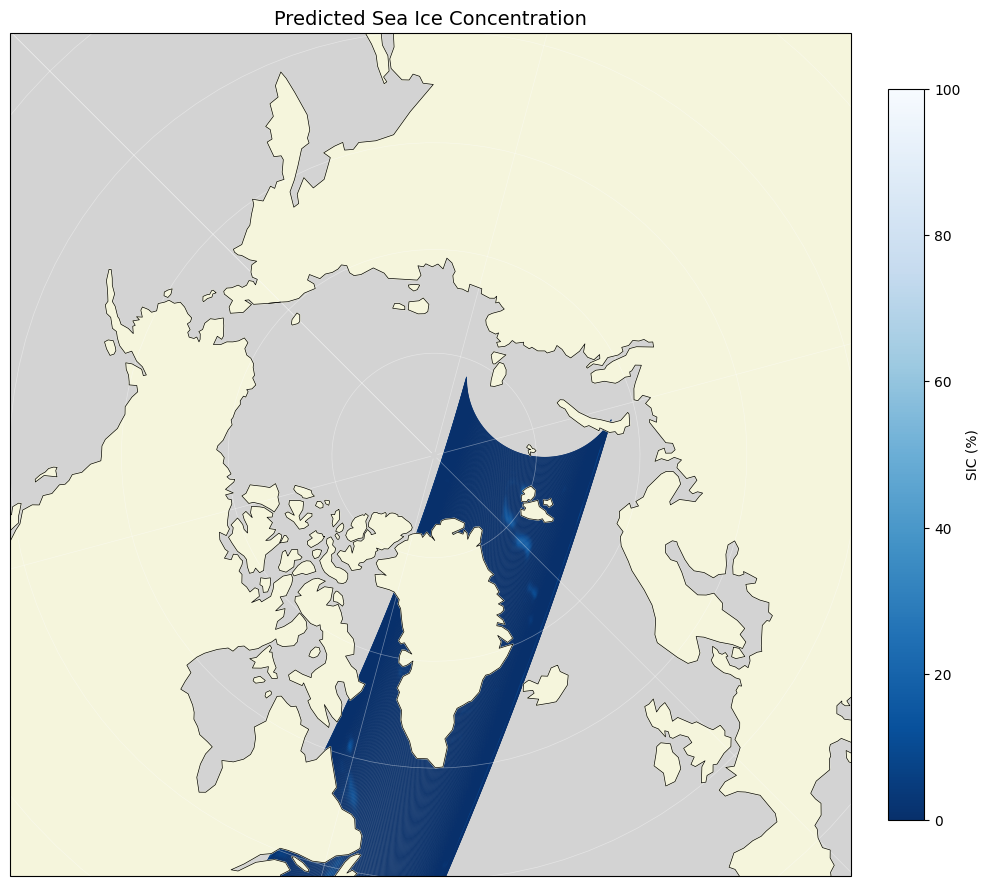

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Downsample lat/lon to match pred_swath shape
# target_h, target_w = pred_swath.shape
# lat_t = torch.from_numpy(lat)[None, None]
# lon_t = torch.from_numpy(lon)[None, None]
# lat_ds = F.interpolate(lat_t, size=(target_h, target_w), mode='bilinear', align_corners=False).numpy()[0, 0]
# lon_ds = F.interpolate(lon_t, size=(target_h, target_w), mode='bilinear', align_corners=False).numpy()[0, 0]

# Flatten and filter to northern hemisphere only
lat_flat = lat.ravel()
lon_flat = lon.ravel()
sic_flat = pred_swath.ravel()

north_mask = (lat_flat >= 50) & (~np.isnan(sic_flat))
# lat_n = lat_flat[north_mask]
# lon_n = lon_flat[north_mask]
# sic_n = sic_flat[north_mask]
lat_n = lat_flat
lon_n = lon_flat
sic_n = sic_flat

# North Polar Stereographic — Greenland centred
proj = ccrs.NorthPolarStereo(central_longitude=-45)

fig, ax = plt.subplots(1, 1, figsize=(10, 10),
                       subplot_kw={'projection': proj})

ax.set_extent([-180, 180, 50, 80], crs=ccrs.PlateCarree())
ax.set_facecolor('lightgray')

sc = ax.scatter(
    lon_n, lat_n, c=sic_n,
    transform=ccrs.PlateCarree(),
    cmap=cmap_sic,
    vmin=0, vmax=100,
    s=0.5,
    linewidths=0,
    zorder=1
)

ax.add_feature(cfeature.LAND, color='beige', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
ax.gridlines(draw_labels=False, linewidth=0.5, color='white', alpha=0.4, zorder=4)

plt.colorbar(sc, ax=ax, orientation='vertical',
             fraction=0.04, pad=0.04, label='SIC (%)')
ax.set_title('Predicted Sea Ice Concentration', fontsize=14)
plt.tight_layout()
plt.show()

Method A prediction shape: (2035, 243) → upsampled to (2035, 486)
Method B prediction shape: (2035, 486)


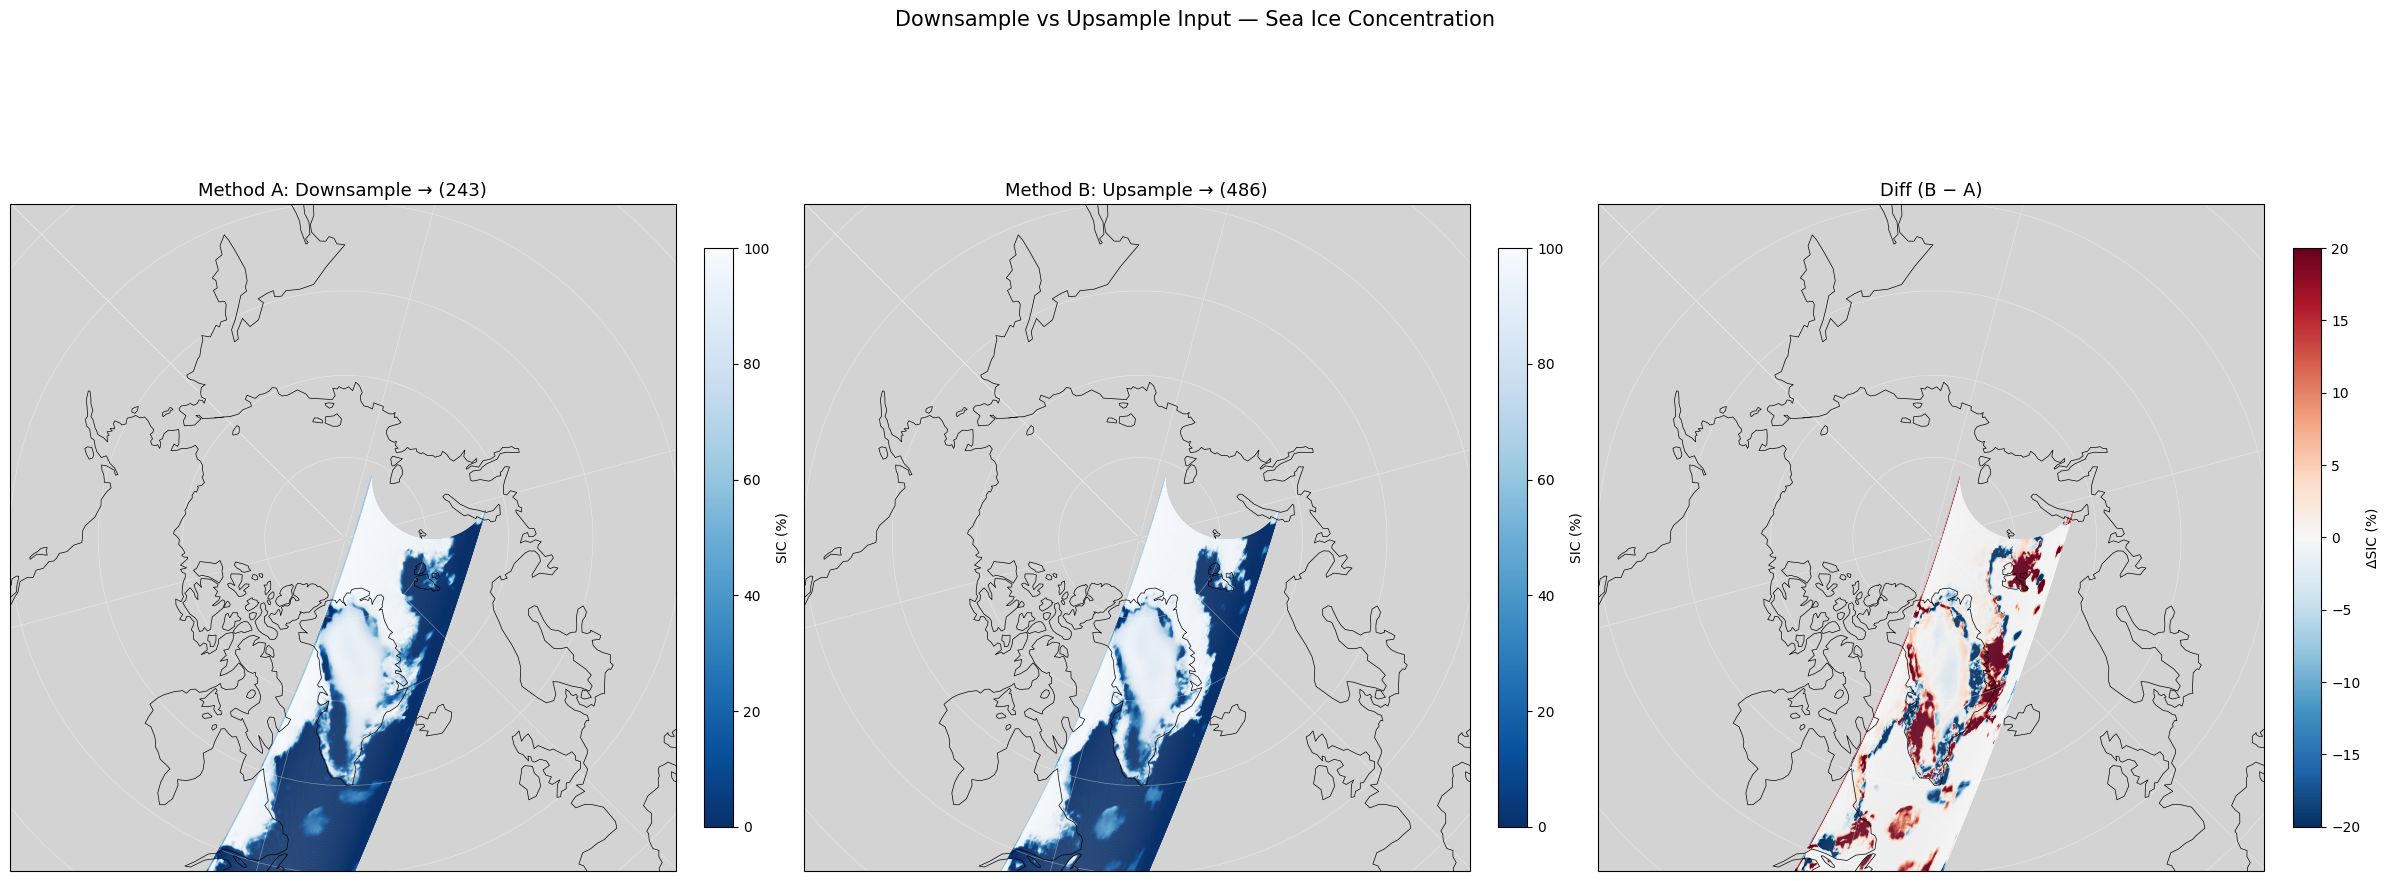

In [13]:
# ── Shared data load ─────────────────────────────────────────────────────
with xr.open_dataset(AMSR2_PATH, engine='h5netcdf', phony_dims='sort') as ds:
    bt_vars_list = list(bt_vars.values())
    arrays = [ds[v].values.astype(np.float32) for v in bt_vars_list]
    lat = ds['Latitude of Observation Point for 89A'].values.astype(np.float32)
    lon = ds['Longitude of Observation Point for 89A'].values.astype(np.float32)

high_h, high_w = lat.shape          # (2035, 486) — 89 GHz
low_h,  low_w  = high_h, high_w//2  # (2035, 243) — low freq

# ── Method A: downsample everything to (2035, 243) ───────────────────────
resampled_A = []
for name, arr in zip(channel_names, arrays):
    if arr.shape != (low_h, low_w):
        t = torch.from_numpy(arr)[None, None]
        t = F.interpolate(t, size=(low_h, low_w), mode='bicubic', align_corners=False)
        arr = t.numpy()[0, 0]
    resampled_A.append(arr)

amsr2_A = np.stack(resampled_A, axis=0) / 100.0
amsr2_A_t = torch.from_numpy(amsr2_A)[None].to(device)
with torch.no_grad():
    pred_A = model(amsr2_A_t, target_size=(low_h, low_w))[0, 0].cpu().numpy()
pred_A = np.clip(pred_A, 0, 100)  # (2035, 243)

# Upsample pred_A to (2035, 486) for fair comparison
pred_A_up = F.interpolate(
    torch.from_numpy(pred_A)[None, None],
    size=(high_h, high_w),
    mode='bicubic',
    align_corners=False
    ).numpy()[0, 0]
pred_A_up = np.clip(pred_A_up, 0, 100)
print(f'Method A prediction shape: {pred_A.shape} → upsampled to {pred_A_up.shape}')

# ── Method B: upsample everything to (2035, 486) ─────────────────────────
resampled_B = []
for name, arr in zip(channel_names, arrays):
    if arr.shape != (high_h, high_w):
        t = torch.from_numpy(arr)[None, None]
        t = F.interpolate(t, size=(high_h, high_w), mode='bicubic', align_corners=False)
        arr = t.numpy()[0, 0]
    resampled_B.append(arr)

amsr2_B = np.stack(resampled_B, axis=0) / 100.0
amsr2_B_t = torch.from_numpy(amsr2_B)[None].to(device)
with torch.no_grad():
    pred_B = model(amsr2_B_t, target_size=(high_h, high_w))[0, 0].cpu().numpy()
pred_B = np.clip(pred_B, 0, 100)  # (2035, 486)
print(f'Method B prediction shape: {pred_B.shape}')

# ── Diff ──────────────────────────────────────────────────────────────────
diff = pred_B - pred_A_up  # (2035, 486)

# ── Plot ──────────────────────────────────────────────────────────────────
def north_points(data):
    lf, lof, sf = lat.ravel(), lon.ravel(), data.ravel()
    mask = (lf >= 50) & (~np.isnan(sf))
    return lof[mask], lf[mask], sf[mask]

fig, axes = plt.subplots(1, 3, figsize=(24, 10),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-45)})

titles   = ['Method A: Downsample → (243)', 'Method B: Upsample → (486)', 'Diff (B − A)']
datasets = [pred_A_up, pred_B, diff]
cmaps    = [cmap_sic, cmap_sic, 'RdBu_r']
vmins    = [0,   0,  -20]
vmaxs    = [100, 100, 20]

for ax, data, title, cmap, vmin, vmax in zip(axes, datasets, titles, cmaps, vmins, vmaxs):
    # lon_n, lat_n, sic_n = north_points(data)
    lon_n, lat_n, sic_n = lon.ravel(), lat.ravel(), data.ravel()

    ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    ax.set_facecolor('lightgray')

    sc = ax.scatter(
        lon_n, lat_n, c=sic_n,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        s=0.3, linewidths=0, zorder=1
    )

    # ax.add_feature(cfeature.LAND, color='gray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.gridlines(draw_labels=False, linewidth=0.5, color='white', alpha=0.4, zorder=4)

    label = 'SIC (%)' if cmap != 'RdBu_r' else 'ΔSIC (%)'
    plt.colorbar(sc, ax=ax, orientation='vertical',
                 fraction=0.04, pad=0.04, label=label)
    ax.set_title(title, fontsize=13)

plt.suptitle('Downsample vs Upsample Input — Sea Ice Concentration', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

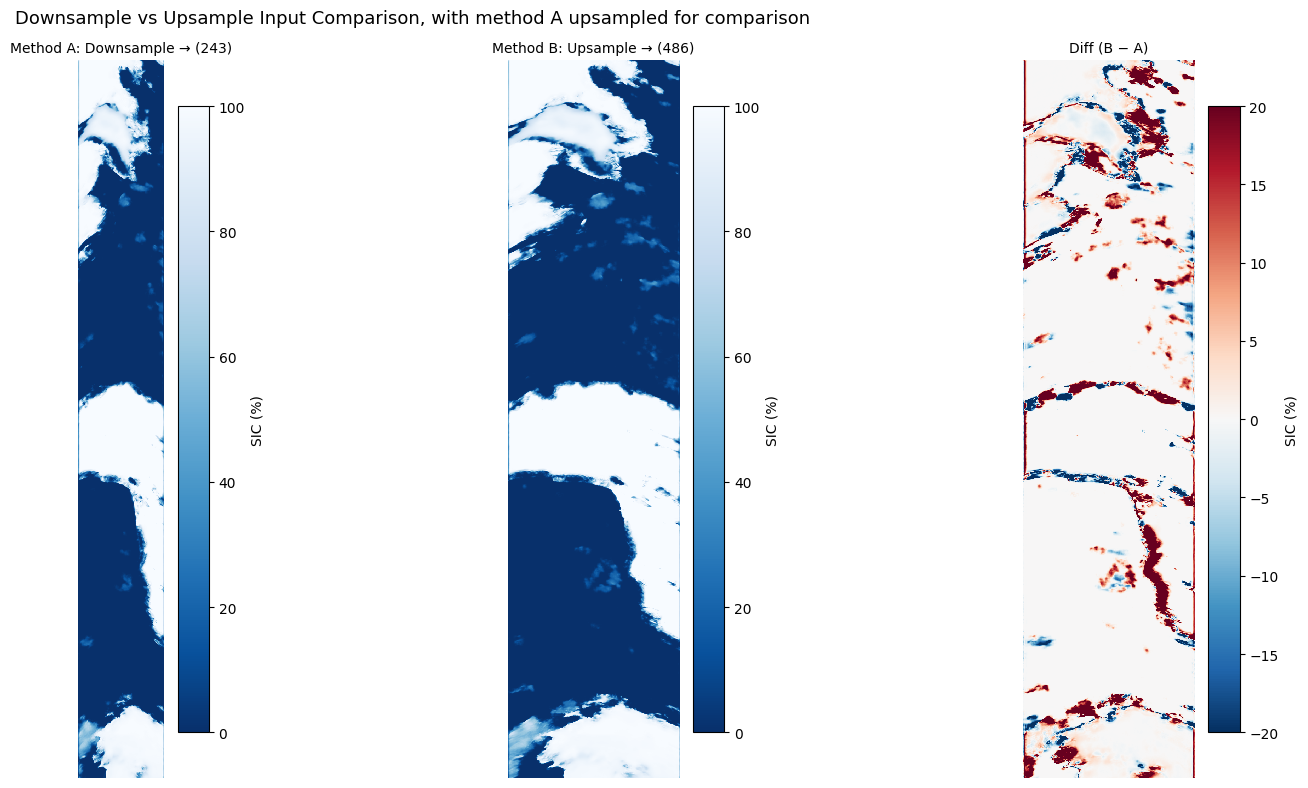

In [14]:
pred_A_up = F.interpolate(
    torch.from_numpy(pred_A)[None, None],
    size=(high_h, high_w),
    mode='bicubic',
    align_corners=False
).numpy()[0, 0]
pred_A_up = np.clip(pred_A_up, 0, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

diff = pred_B - pred_A_up
datasets = [pred_A, pred_B, diff]
titles   = ['Method A: Downsample → (243)', 'Method B: Upsample → (486)', 'Diff (B − A)']
cmaps    = [cmap_sic, cmap_sic, 'RdBu_r']
vmins    = [0,   0,  -20]
vmaxs    = [100, 100, 20]

for ax, data, title, cmap, vmin, vmax in zip(axes, datasets, titles, cmaps, vmins, vmaxs):
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='SIC (%)')

plt.suptitle('Downsample vs Upsample Input Comparison, with method A upsampled for comparison', fontsize=13)
plt.tight_layout()
plt.show()

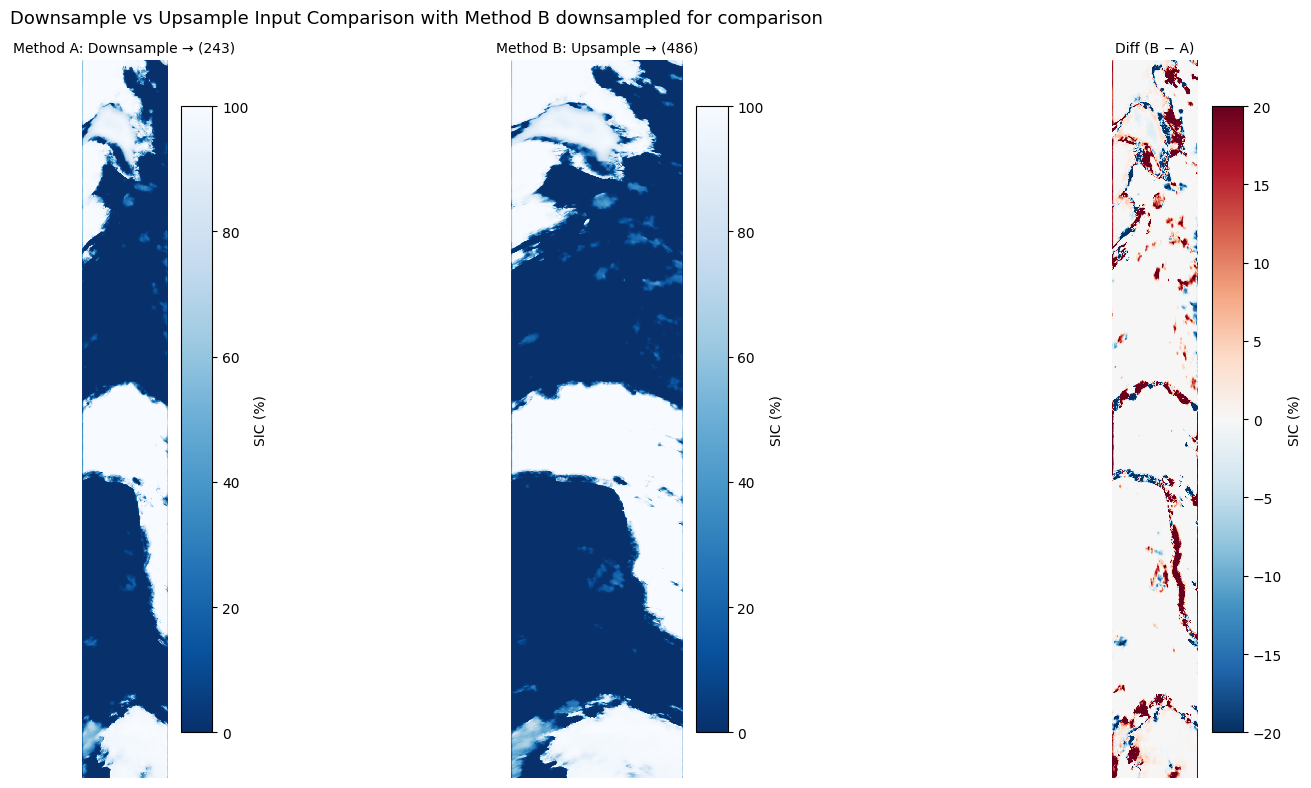

In [15]:
pred_B_down = F.interpolate(
    torch.from_numpy(pred_B)[None, None],
    size=(low_h, low_w),
    mode='bicubic',
    align_corners=False
).numpy()[0, 0]
pred_B_down = np.clip(pred_B_down, 0, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

diff = pred_B_down - pred_A
datasets = [pred_A, pred_B, diff]
titles   = ['Method A: Downsample → (243)', 'Method B: Upsample → (486)', 'Diff (B − A)']
cmaps    = [cmap_sic, cmap_sic, 'RdBu_r']
vmins    = [0,   0,  -20]
vmaxs    = [100, 100, 20]

for ax, data, title, cmap, vmin, vmax in zip(axes, datasets, titles, cmaps, vmins, vmaxs):
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='SIC (%)')

plt.suptitle('Downsample vs Upsample Input Comparison with Method B downsampled for comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
data_dir = '/dmidata/projects/asip-cms/amsr2/2021/02/04/'
files = sorted(f for f in os.listdir(data_dir) if f.endswith('.h5'))
date_str = '2021-02-04'

results = []  # list of (lon_n, lat_n, sic_n, t_norm)

for fname in tqdm(files, desc='Predicting swaths'):
    fpath = os.path.join(data_dir, fname)

    ts = fname.split('_')[1]
    dt = datetime.strptime(ts, '%Y%m%d%H%M')
    t_norm = (dt.hour * 60 + dt.minute) / (24 * 60)

    try:
        with xr.open_dataset(fpath, engine='h5netcdf', phony_dims='sort') as ds:
            arrays = [ds[v].values.astype(np.float32) for v in bt_vars.values()]
            lat_f  = ds['Latitude of Observation Point for 89A'].values.astype(np.float32)
            lon_f  = ds['Longitude of Observation Point for 89A'].values.astype(np.float32)

        high_h, high_w = lat_f.shape

        resampled = []
        for arr in arrays:
            if arr.shape != (high_h, high_w):
                t = torch.from_numpy(arr)[None, None]
                t = F.interpolate(t, size=(high_h, high_w), mode='bicubic', align_corners=False)
                arr = t.numpy()[0, 0]
            resampled.append(arr)

        amsr2 = np.stack(resampled, axis=0)[None] / 100.0
        with torch.no_grad():
            pred = model(torch.from_numpy(amsr2).to(device),
                         target_size=(high_h, high_w))[0, 0].cpu().numpy()
        pred = np.clip(pred, 0, 100)

        mask = (lat_f >= 50) & (~np.isnan(pred))
        if mask.sum() == 0:
            continue

        results.append((lon_f[mask], lat_f[mask], pred[mask], t_norm))

    except Exception:
        pass

Predicting swaths:  34%|███▍      | 10/29 [03:03<06:10, 19.50s/it]

In [ ]:
proj = ccrs.NorthPolarStereo(central_longitude=-45)
fig, axes = plt.subplots(1, 2, figsize=(20, 10), subplot_kw={'projection': proj})

time_cmap = plt.get_cmap('hsv')

for ax in axes:
    ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    ax.set_facecolor('black')
    ax.add_feature(cfeature.LAND, color='gray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.5, color='white', alpha=0.4, zorder=5)

axes[0].set_title(f'SIC prediction for {date_str}', fontsize=13)
axes[1].set_title(f'Swath timestamps for {date_str}', fontsize=13)

sic_sc = None
for lon_n, lat_n, sic_n, t_norm in results:
    sic_sc = axes[0].scatter(
        lon_n, lat_n, c=sic_n,
        transform=ccrs.PlateCarree(),
        cmap=cmap_sic, vmin=0, vmax=100,
        s=2, linewidths=0, zorder=2, rasterized=True
    )
    axes[1].scatter(
        lon_n, lat_n,
        color=time_cmap(t_norm),
        transform=ccrs.PlateCarree(),
        s=2, linewidths=0, zorder=2, rasterized=True
    )

if sic_sc is not None:
    plt.colorbar(sic_sc, ax=axes[0], fraction=0.04, pad=0.04, label='SIC (%)')

sm = plt.cm.ScalarMappable(cmap=time_cmap, norm=mcolors.Normalize(vmin=0, vmax=24))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[1], fraction=0.04, pad=0.04, label='Hour (UTC)')
cbar.set_ticks(np.arange(0, 25, 3))
cbar.set_ticklabels([f'{h:02d}:00' for h in range(0, 25, 3)])

plt.suptitle(f'AMSR2 — {date_str}', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()